# 04 — Modeling & MLflow Tracking

> **Hurdle Model (Two-Stage Prediction)**
>
> - **Stage 1 (Classification)**: Predict `P(sold_to_third_party)` for all offered lots
> - **Stage 2 (Regression)**: Predict `log(price_gns)` conditioned on sale
> - **Combined**: `E[price] = P(sold) × exp(log_price_pred + σ²/2)` — market-value estimate for every lot

---

## Experimental Setup

| Aspect | Setting |
|---|---|
| **Metric** | PR-AUC (dev), AUC-ROC (report) — Stage 1 · RMSE log (opt), MAPE/MdAPE (report) — Stage 2 |
| **Temporal Split** | Train 2009–2019 · Val 2020–2021 · Test 2022–2025 (OOT, touched once) |
| **Reproducibility** | Seed = 42 (PYTHONHASHSEED, numpy, random) |
| **MLflow** | Tracking URI `./mlruns/` — full hyperparameter & metric logging |
| **Optuna** | TPE sampler, TimeSeriesSplit(4) or early-stopping eval set |
| **Pruning** | MedianPruner on XGBoost, LightGBM, CatBoost trials |

## Models Compared

| Stage 1 (Classification) | Stage 2 (Regression) |
|---|---|
| Logistic Regression (baseline) | Ridge Regression (baseline) |
| Random Forest | Random Forest Regressor |
| XGBoost (hist, n_jobs=-1) | XGBoost Regressor |
| LightGBM (n_jobs=-1) | LightGBM Regressor |
| CatBoost (thread_count=-1) | CatBoost Regressor |
| **Stacking** (LR meta) | **Stacking** (Ridge meta) |

In [42]:
import os, sys, warnings, random, json, math

# reproducibility
RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)

# core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, confusion_matrix, precision_recall_curve, roc_curve,
    mean_squared_error
)

# boosting frameworks
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
import xgboost as xgb
import lightgbm as lgb

# optuna + mlflow
import optuna
from optuna.integration.mlflow import MLflowCallback
from optuna.pruners import MedianPruner
from mlflow.tracking import MlflowClient
import mlflow

# project imports
from pathlib import Path
PROJECT_ROOT = Path('').resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.constants import TRAIN_MAX_YEAR, VAL_MIN_YEAR, VAL_MAX_YEAR, TEST_MIN_YEAR

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("./mlruns")

# suppress
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"xgboost  : {xgb.__version__}")
print(f"lightgbm : {lgb.__version__}")

xgboost  : 3.2.0
lightgbm : 4.6.0


In [43]:
# ── paths ──
DATA_DIR = "../data/processed"
CLASS_PATH = f"{DATA_DIR}/classification_ready.parquet"
REG_PATH    = f"{DATA_DIR}/regression_ready.parquet"
UNIV_PATH   = f"{DATA_DIR}/inference_universe.parquet"

# ── feature doc ──
feat_doc = pd.read_csv(f"{DATA_DIR}/feature_documentation.csv")
features_clf = feat_doc[feat_doc["model"] == "classification"]["feature"].tolist()
features_reg = feat_doc[feat_doc["model"] == "regression"]["feature"].tolist()
print(f"features_clf: {len(features_clf)}")
print(f"features_reg: {len(features_reg)}")

# ── MLflow experiments ──
MLFLOW_EXP_CLF = "stage1_classification"
MLFLOW_EXP_REG = "stage2_regression"

features_clf: 52
features_reg: 41


In [44]:
# Load datasets
clf_df = pd.read_parquet(CLASS_PATH)
reg_df = pd.read_parquet(REG_PATH)
univ_df = pd.read_parquet(UNIV_PATH)

print("classification_ready:", clf_df.shape)
print("regression_ready   :", reg_df.shape)
print("inference_universe :", univ_df.shape)
print("Year ranges:", clf_df['sale_year'].min(), "-", clf_df['sale_year'].max())

classification_ready: (18989, 57)
regression_ready   : (16527, 47)
inference_universe : (18989, 64)
Year ranges: 2009 - 2025


In [45]:
# ── Stage 1 splits ──
clf_train = clf_df[clf_df['sale_year'] <= TRAIN_MAX_YEAR].copy()
clf_val   = clf_df[(clf_df['sale_year'] >= VAL_MIN_YEAR) & (clf_df['sale_year'] <= VAL_MAX_YEAR)].copy()
clf_test  = clf_df[clf_df['sale_year'] >= TEST_MIN_YEAR].copy()

# ── Stage 2 splits ──
reg_train = reg_df[reg_df['sale_year'] <= TRAIN_MAX_YEAR].copy()
reg_val   = reg_df[(reg_df['sale_year'] >= VAL_MIN_YEAR) & (reg_df['sale_year'] <= VAL_MAX_YEAR)].copy()
reg_test  = reg_df[reg_df['sale_year'] >= TEST_MIN_YEAR].copy()

print("=== Stage 1 ===")
print(f"Train: {clf_train.shape[0]} rows ({clf_train['sale_year'].min()}-{clf_train['sale_year'].max()})")
print(f"Val  : {clf_val.shape[0]} rows ({clf_val['sale_year'].min()}-{clf_val['sale_year'].max()})")
print(f"Test : {clf_test.shape[0]} rows ({clf_test['sale_year'].min()}-{clf_test['sale_year'].max()})")
print("\n=== Stage 2 ===")
print(f"Train: {reg_train.shape[0]} rows ({reg_train['sale_year'].min()}-{reg_train['sale_year'].max()})")
print(f"Val  : {reg_val.shape[0]} rows ({reg_val['sale_year'].min()}-{reg_val['sale_year'].max()})")
print(f"Test : {reg_test.shape[0]} rows ({reg_test['sale_year'].min()}-{reg_test['sale_year'].max()})")
print("Sold ratio (train):", reg_train['sold_to_third_party'].mean().round(3))
print("Sold ratio (val)  :", reg_val['sold_to_third_party'].mean().round(3))
print("Sold ratio (test) :", reg_test['sold_to_third_party'].mean().round(3))
print("Sold ratio (test) :", clf_test['sold_to_third_party'].mean().round(3))
# Ensure chronologically sorted for TimeSeriesSplit later
clf_train = clf_train.sort_values(by=['sale_year', 'day', 'lot'])
reg_train = reg_train.sort_values(by=['sale_year', 'day', 'lot'])


=== Stage 1 ===
Train: 12097 rows (2009-2019)
Val  : 2198 rows (2020-2021)
Test : 4694 rows (2022-2025)

=== Stage 2 ===
Train: 10424 rows (2009-2019)
Val  : 1971 rows (2020-2021)
Test : 4132 rows (2022-2025)
Sold ratio (train): 1.0
Sold ratio (val)  : 1.0
Sold ratio (test) : 1.0
Sold ratio (test) : 0.88


## Stage 1 — Classification: P(sold_to_third_party)

### Strategy

Six models are trained and compared:

1. **Logistic Regression** — calibrated baseline (balanced weights, saga solver)
2. **Random Forest** — 25 Optuna trials, 4-fold temporal CV on PR-AUC, parallel via `n_jobs=-1`
3. **XGBoost** — 50 Optuna trials, hist tree method, early stopping + MedianPruner, class weight via `scale_pos_weight`
4. **LightGBM** — 50 Optuna trials, native PR-AUC eval metric, early stopping + MedianPruner
5. **CatBoost** — 30 Optuna trials, auto-class-weights, temporal 80/20 eval for early stopping + MedianPruner
6. **Stacking Classifier** — val-based meta-learner (Logistic Regression) over the four tree-model predictions; avoids OOF to preserve temporal integrity

In [46]:
mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)

X_train = clf_train[features_clf]
X_val   = clf_val[features_clf]
X_test  = clf_test[features_clf]
y_train = clf_train['sold_to_third_party']
y_val   = clf_val['sold_to_third_party']
y_test  = clf_test['sold_to_third_party']

with mlflow.start_run(run_name="baseline_logistic_regression"):
    # saga converges faster than lbfgs on large datasets with many features
    lr = LogisticRegression(class_weight='balanced', max_iter=5000,
                             solver='saga', random_state=RANDOM_SEED, C=1.0)
    lr.fit(X_train, y_train)

    prob_val  = lr.predict_proba(X_val)[:, 1]
    prob_test = lr.predict_proba(X_test)[:, 1]

    roc_val   = roc_auc_score(y_val, prob_val)
    pr_val    = average_precision_score(y_val, prob_val)
    brier_val = brier_score_loss(y_val, prob_val)

    mlflow.log_params({"C": 1.0, "solver": "saga", "class_weight": "balanced", "model": "LogisticRegression"})
    mlflow.log_metrics({"val_roc_auc": roc_val, "val_pr_auc": pr_val, "val_brier": brier_val})
    mlflow.sklearn.log_model(lr, "model")

    print(f"LR  | Val  ROC-AUC={roc_val:.4f}  PR-AUC={pr_val:.4f}  Brier={brier_val:.4f}")

2026/05/11 18:08:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:08:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 18:08:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LR  | Val  ROC-AUC=0.6191  PR-AUC=0.9313  Brier=0.1810


In [47]:
def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 600)
    max_depth = trial.suggest_int("max_depth", 4, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5])

    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth if max_depth < 20 else None,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        max_features=max_features, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1,
    )
    tscv = TimeSeriesSplit(n_splits=4)
    scores = cross_val_score(rf, clf_train[features_clf], y_train,
                              cv=tscv, scoring="average_precision", n_jobs=1)
    return scores.mean()

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
_exp_id_clf = mlflow.get_experiment_by_name(MLFLOW_EXP_CLF).experiment_id
mlf_cb = MLflowCallback(
    metric_name="val_pr_auc",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_clf}
)

with mlflow.start_run(run_name="random_forest_optuna") as run:
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective_rf, n_trials=25, callbacks=[mlf_cb])

    best = study.best_params
    mlflow.log_params({"model": "RandomForest", **best})
    print("Best RF params:", best)

    rf_best = RandomForestClassifier(
        n_estimators=best["n_estimators"],
        max_depth=best["max_depth"] if best["max_depth"] < 20 else None,
        min_samples_split=best["min_samples_split"],
        min_samples_leaf=best["min_samples_leaf"],
        max_features=best["max_features"],
        class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
    )
    rf_best.fit(X_train, y_train)

    prob_val_rf  = rf_best.predict_proba(X_val)[:, 1]
    prob_test_rf = rf_best.predict_proba(X_test)[:, 1]

    roc_val_rf   = roc_auc_score(y_val, prob_val_rf)
    pr_val_rf    = average_precision_score(y_val, prob_val_rf)
    brier_val_rf = brier_score_loss(y_val, prob_val_rf)

    mlflow.log_metrics({"val_roc_auc": roc_val_rf, "val_pr_auc": pr_val_rf, "val_brier": brier_val_rf})
    mlflow.sklearn.log_model(rf_best, "model")

    print(f"RF  | Val  ROC-AUC={roc_val_rf:.4f}  PR-AUC={pr_val_rf:.4f}  Brier={brier_val_rf:.4f}")

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_42780/89877161.py:22: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlf_cb = MLflowCallback(
2026/05/11 18:08:59 INFO mlflow.tracking.fluent: Experiment with name 'no-name-25a74843-5a1b-47c1-83dd-321e6c8f26b9' does not exist. Creating a new experiment.


Best RF params: {'n_estimators': 396, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 0.5}


2026/05/11 18:09:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:09:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 18:09:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


RF  | Val  ROC-AUC=0.6461  PR-AUC=0.9383  Brier=0.1796


In [48]:
# ── XGBoost (Stage 1) — CPU multi-thread, hist tree method, early stopping ──
_split_idx_clf = int(len(X_train) * 0.8)
_yr_train = clf_train['sale_year']
assert _yr_train.iloc[:_split_idx_clf].max() <= _yr_train.iloc[_split_idx_clf:].min(), \
    "XGBoost split violates temporal order"

X_tr_xgb, X_ev_xgb = X_train.iloc[:_split_idx_clf], X_train.iloc[_split_idx_clf:]
y_tr_xgb, y_ev_xgb = y_train.iloc[:_split_idx_clf], y_train.iloc[_split_idx_clf:]
_scale_pos = (y_tr_xgb == 0).sum() / max((y_tr_xgb == 1).sum(), 1)

def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    pruning_cb = optuna.integration.XGBoostPruningCallback(trial, "validation_0-aucpr")
    model = xgb.XGBClassifier(
        **params,
        tree_method="hist", device="cpu", n_jobs=-1,
        scale_pos_weight=_scale_pos, eval_metric="aucpr",
        random_state=RANDOM_SEED, early_stopping_rounds=30, verbosity=0,
        callbacks=[pruning_cb],
    )
    model.fit(X_tr_xgb, y_tr_xgb, eval_set=[(X_ev_xgb, y_ev_xgb)], verbose=False)
    prob = model.predict_proba(X_ev_xgb)[:, 1]
    return average_precision_score(y_ev_xgb, prob)

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
_exp_id_clf = mlflow.get_experiment_by_name(MLFLOW_EXP_CLF).experiment_id
mlf_cb_xgb = MLflowCallback(
    metric_name="val_pr_auc",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_clf}
)

with mlflow.start_run(run_name="xgboost_optuna") as run:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_xgb, n_trials=50, callbacks=[mlf_cb_xgb])

    bp_xgb = study.best_params
    mlflow.log_params({"model": "XGBoost", **bp_xgb})
    print("Best XGB params:", bp_xgb)

    xgb_best = xgb.XGBClassifier(
        **bp_xgb,
        tree_method="hist", device="cpu", n_jobs=-1,
        scale_pos_weight=_scale_pos, eval_metric="aucpr",
        random_state=RANDOM_SEED, verbosity=0,
    )
    xgb_best.fit(X_train, y_train, verbose=False)

    prob_val_xgb  = xgb_best.predict_proba(X_val)[:, 1]
    prob_test_xgb = xgb_best.predict_proba(X_test)[:, 1]

    roc_val_xgb   = roc_auc_score(y_val, prob_val_xgb)
    pr_val_xgb    = average_precision_score(y_val, prob_val_xgb)
    brier_val_xgb = brier_score_loss(y_val, prob_val_xgb)

    mlflow.log_metrics({"val_roc_auc": roc_val_xgb, "val_pr_auc": pr_val_xgb, "val_brier": brier_val_xgb})
    mlflow.xgboost.log_model(xgb_best, "model")

    print(f"XGB | Val  ROC-AUC={roc_val_xgb:.4f}  PR-AUC={pr_val_xgb:.4f}  Brier={brier_val_xgb:.4f}")

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_42780/3396275108.py:35: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlf_cb_xgb = MLflowCallback(
2026/05/11 18:09:56 INFO mlflow.tracking.fluent: Experiment with name 'no-name-cf732add-0f23-4cd5-baf2-2d16c2f47c26' does not exist. Creating a new experiment.


Best XGB params: {'n_estimators': 598, 'learning_rate': 0.17310856382823195, 'max_depth': 4, 'reg_lambda': 6.008515705585437, 'subsample': 0.9464386213360442, 'colsample_bytree': 0.8178024043672255}


2026/05/11 18:10:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:10:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGB | Val  ROC-AUC=0.6311  PR-AUC=0.9306  Brier=0.1123


In [49]:
# ── LightGBM (Stage 1) — CPU multi-thread, native PR-AUC eval ──
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }
    pruning_cb = optuna.integration.LightGBMPruningCallback(trial, "average_precision")
    model = lgb.LGBMClassifier(
        **params,
        objective="binary", metric="average_precision",
        class_weight="balanced", random_state=RANDOM_SEED,
        n_jobs=-1, subsample_freq=1, verbose=-1,
    )
    model.fit(
        X_tr_xgb, y_tr_xgb,
        eval_set=[(X_ev_xgb, y_ev_xgb)],
        eval_metric="average_precision",
        callbacks=[lgb.early_stopping(30, verbose=False), pruning_cb],
    )
    prob = model.predict_proba(X_ev_xgb)[:, 1]
    return average_precision_score(y_ev_xgb, prob)

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
_exp_id_clf = mlflow.get_experiment_by_name(MLFLOW_EXP_CLF).experiment_id
mlf_cb_lgbm = MLflowCallback(
    metric_name="val_pr_auc",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_clf}
)

with mlflow.start_run(run_name="lightgbm_optuna") as run:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_lgbm, n_trials=50, callbacks=[mlf_cb_lgbm])

    bp_lgbm = study.best_params
    mlflow.log_params({"model": "LightGBM", **bp_lgbm})
    print("Best LGBM params:", bp_lgbm)

    lgbm_best = lgb.LGBMClassifier(
        **bp_lgbm,
        objective="binary", class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1, subsample_freq=1, verbose=-1,
    )
    lgbm_best.fit(X_train, y_train)

    prob_val_lgbm  = lgbm_best.predict_proba(X_val)[:, 1]
    prob_test_lgbm = lgbm_best.predict_proba(X_test)[:, 1]

    roc_val_lgbm   = roc_auc_score(y_val, prob_val_lgbm)
    pr_val_lgbm    = average_precision_score(y_val, prob_val_lgbm)
    brier_val_lgbm = brier_score_loss(y_val, prob_val_lgbm)

    mlflow.log_metrics({"val_roc_auc": roc_val_lgbm, "val_pr_auc": pr_val_lgbm, "val_brier": brier_val_lgbm})
    mlflow.lightgbm.log_model(lgbm_best, "model")

    print(f"LGBM | Val  ROC-AUC={roc_val_lgbm:.4f}  PR-AUC={pr_val_lgbm:.4f}  Brier={brier_val_lgbm:.4f}")

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_42780/410958102.py:31: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlf_cb_lgbm = MLflowCallback(
2026/05/11 18:10:16 INFO mlflow.tracking.fluent: Experiment with name 'no-name-5d24b3cf-cafc-4987-b555-34328ce1ab49' does not exist. Creating a new experiment.


Best LGBM params: {'n_estimators': 687, 'learning_rate': 0.011062383243962626, 'num_leaves': 182, 'reg_lambda': 1.8271695985358454, 'subsample': 0.6779196613035873, 'colsample_bytree': 0.5800789728943497, 'min_child_samples': 95}


2026/05/11 18:11:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:11:13 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 18:11:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LGBM | Val  ROC-AUC=0.6351  PR-AUC=0.9331  Brier=0.1235


In [50]:
def objective_cb(trial):
    iterations = trial.suggest_int("iterations", 200, 1000)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    depth = trial.suggest_int("depth", 4, 10)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1, 10, log=True)
    bagging_temp = trial.suggest_float("bagging_temperature", 0.0, 1.0)

    split_idx = int(len(X_train) * 0.8)
    X_tr, X_ev = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
    y_tr, y_ev = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

    train_years = clf_train['sale_year']
    first_half_max = train_years.iloc[:split_idx].max()
    second_half_min = train_years.iloc[split_idx:].min()
    assert first_half_max <= second_half_min, (
        f"CatBoost split violates temporal order: "
        f"first 80% max year={first_half_max}, last 20% min year={second_half_min}"
    )

    cb = CatBoostClassifier(
        iterations=iterations, learning_rate=learning_rate, depth=depth,
        l2_leaf_reg=l2_leaf_reg, bagging_temperature=bagging_temp,
        loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_SEED, verbose=False, thread_count=-1,
        auto_class_weights="Balanced", early_stopping_rounds=50,
    )
    cb.fit(X_tr, y_tr, eval_set=(X_ev, y_ev), use_best_model=True)
    return cb.best_score_['validation']['AUC']

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
_exp_id_clf = mlflow.get_experiment_by_name(MLFLOW_EXP_CLF).experiment_id
mlf_cb_clf = MLflowCallback(
    metric_name="val_pr_auc",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_clf}
)

with mlflow.start_run(run_name="catboost_optuna") as run:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_cb, n_trials=30, callbacks=[mlf_cb_clf])

    best_cb = study.best_params
    mlflow.log_params({"model": "CatBoost", **best_cb})
    print("Best CB params:", best_cb)

    cb_best = CatBoostClassifier(
        iterations=best_cb["iterations"], learning_rate=best_cb["learning_rate"],
        depth=best_cb["depth"], l2_leaf_reg=best_cb["l2_leaf_reg"],
        bagging_temperature=best_cb["bagging_temperature"],
        loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_SEED, verbose=False, thread_count=-1,
        auto_class_weights="Balanced", early_stopping_rounds=50,
    )
    cb_best.fit(X_train, y_train, verbose=False)

    prob_val_cb  = cb_best.predict_proba(X_val)[:, 1]
    prob_test_cb = cb_best.predict_proba(X_test)[:, 1]

    roc_val_cb   = roc_auc_score(y_val, prob_val_cb)
    pr_val_cb    = average_precision_score(y_val, prob_val_cb)
    brier_val_cb = brier_score_loss(y_val, prob_val_cb)

    mlflow.log_metrics({"val_roc_auc": roc_val_cb, "val_pr_auc": pr_val_cb, "val_brier": brier_val_cb})
    mlflow.catboost.log_model(cb_best, "model")

    print(f"CatBoost | Val  ROC-AUC={roc_val_cb:.4f}  PR-AUC={pr_val_cb:.4f}  Brier={brier_val_cb:.4f}")

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_42780/852954491.py:33: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlf_cb_clf = MLflowCallback(
2026/05/11 18:11:16 INFO mlflow.tracking.fluent: Experiment with name 'no-name-8d41c081-1ef0-4334-ba90-f604b1afa027' does not exist. Creating a new experiment.


Best CB params: {'iterations': 538, 'learning_rate': 0.03551810111228509, 'depth': 6, 'l2_leaf_reg': 1.8962626253540724, 'bagging_temperature': 0.8623167056786356}


2026/05/11 18:11:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:11:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


CatBoost | Val  ROC-AUC=0.6472  PR-AUC=0.9347  Brier=0.1188


In [51]:
# ── Stage 1 Stacking — val-based, temporal-clean ──
# Base models trained on TRAIN; their VAL predictions become meta-features for an LR meta-learner.
# Avoids OOF (which would leak across temporal folds) while still letting the meta-learner
# learn optimal weights between base models.

base_clf_runs = {
    "rf":   prob_val_rf,
    "xgb":  prob_val_xgb,
    "lgbm": prob_val_lgbm,
    "cb":   prob_val_cb,
}
base_clf_test = {
    "rf":   prob_test_rf,
    "xgb":  prob_test_xgb,
    "lgbm": prob_test_lgbm,
    "cb":   prob_test_cb,
}

Z_val_clf  = np.column_stack([base_clf_runs[k]  for k in ["rf", "xgb", "lgbm", "cb"]])
Z_test_clf = np.column_stack([base_clf_test[k] for k in ["rf", "xgb", "lgbm", "cb"]])

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
with mlflow.start_run(run_name="stacking_classifier"):
    meta_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
    meta_clf.fit(Z_val_clf, y_val)

    prob_val_stk  = meta_clf.predict_proba(Z_val_clf)[:, 1]
    prob_test_stk = meta_clf.predict_proba(Z_test_clf)[:, 1]

    roc_val_stk   = roc_auc_score(y_val, prob_val_stk)
    pr_val_stk    = average_precision_score(y_val, prob_val_stk)
    brier_val_stk = brier_score_loss(y_val, prob_val_stk)

    weights = dict(zip(["rf", "xgb", "lgbm", "cb"], meta_clf.coef_[0].round(4)))
    mlflow.log_params({"model": "StackingClassifier", "meta": "LogisticRegression", **{f"w_{k}": v for k, v in weights.items()}})
    mlflow.log_metrics({"val_roc_auc": roc_val_stk, "val_pr_auc": pr_val_stk, "val_brier": brier_val_stk})
    mlflow.sklearn.log_model(meta_clf, "model")

    print(f"Stacking | Val  ROC-AUC={roc_val_stk:.4f}  PR-AUC={pr_val_stk:.4f}  Brier={brier_val_stk:.4f}")
    print(f"Meta-learner weights: {weights}")

2026/05/11 18:11:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:11:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 18:11:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Stacking | Val  ROC-AUC=0.6521  PR-AUC=0.9382  Brier=0.0894
Meta-learner weights: {'rf': np.float64(1.3907), 'xgb': np.float64(0.4422), 'lgbm': np.float64(0.8465), 'cb': np.float64(1.5125)}


In [52]:
# Stage 1 comparison — val metrics only (test set touched once in final eval cell)
# IMPORTANT: filter out nested Optuna trial runs — keep only the 6 top-level.
TOP_CLF_RUNS = {
    "baseline_logistic_regression",
    "random_forest_optuna",
    "xgboost_optuna",
    "lightgbm_optuna",
    "catboost_optuna",
    "stacking_classifier",
}

client = MlflowClient()
exp = client.get_experiment_by_name(MLFLOW_EXP_CLF)
all_runs = client.search_runs(exp.experiment_id)
runs = [r for r in all_runs if r.info.run_name in TOP_CLF_RUNS]

data = []
for r in runs:
    p = r.data.params
    m = r.data.metrics
    data.append({
        "run": r.info.run_name,
        "model": p.get("model", "?"),
        "val_roc_auc": round(m.get("val_roc_auc", 0), 4),
        "val_pr_auc":  round(m.get("val_pr_auc", 0), 4),
        "val_brier":   round(m.get("val_brier", float("nan")), 4),
    })

display(pd.DataFrame(data).sort_values("val_pr_auc", ascending=False))

,run,model,val_roc_auc,val_pr_auc,val_brier
10,random_forest_optuna,RandomForest,0.6461,0.9383,0.1796
4,random_forest_optuna,RandomForest,0.6461,0.9383,0.1796
13,random_forest_optuna,RandomForest,0.6461,0.9383,0.1796
0,stacking_classifier,StackingClassifier,0.6521,0.9382,0.0894
6,stacking_classifier,StackingClassifier,0.6521,0.9382,0.0894
38,stacking_classifier,StackingClassifier,0.6414,0.9352,0.0899
32,stacking_classifier,StackingClassifier,0.6414,0.9352,0.0899
26,stacking_classifier,StackingClassifier,0.6414,0.9352,0.0899
20,stacking_classifier,StackingClassifier,0.6414,0.9352,0.0899
30,random_forest_optuna,RandomForest,0.6376,0.9350,0.1689


In [53]:
# Determine best model by val PR-AUC (across all 6)
from src.model_wrappers import StackingClassifierWrapper

stacking_clf_wrapper = StackingClassifierWrapper(
    base_models={"rf": rf_best, "xgb": xgb_best, "lgbm": lgbm_best, "cb": cb_best},
    meta=meta_clf,
    base_keys=["rf", "xgb", "lgbm", "cb"],
)

all_clf_candidates = {
    "baseline_logistic_regression": (prob_val,      prob_test,      lr,                   True),
    "random_forest_optuna":         (prob_val_rf,   prob_test_rf,   rf_best,              False),
    "xgboost_optuna":               (prob_val_xgb,  prob_test_xgb,  xgb_best,             False),
    "lightgbm_optuna":              (prob_val_lgbm, prob_test_lgbm, lgbm_best,            False),
    "catboost_optuna":              (prob_val_cb,   prob_test_cb,   cb_best,              False),
    "stacking_classifier":          (prob_val_stk,  prob_test_stk,  stacking_clf_wrapper, True),
}

# Select best model using in-memory metrics (independent of MLflow query state)
_pr_auc_in_memory = {name: average_precision_score(y_val, vals[0]) for name, vals in all_clf_candidates.items()}
best_run_name = max(_pr_auc_in_memory, key=_pr_auc_in_memory.get)
print("Best Stage 1 model:", best_run_name, f"(val PR-AUC={_pr_auc_in_memory[best_run_name]:.4f})")
# Look up MLflow run for run_id export (Cell 30)
best_run = next((r for r in runs if r.info.run_name == best_run_name), None)

best_prob_val, best_prob_test, clf_best_artifact, already_calibrated = all_clf_candidates[best_run_name]

if not already_calibrated:
    print("Calibrating with isotonic regression...")
    clf_calibrated = CalibratedClassifierCV(clf_best_artifact, method="isotonic", cv=3)
    clf_calibrated.fit(X_val, y_val)
    best_prob_val_cal  = clf_calibrated.predict_proba(X_val)[:, 1]
    best_prob_test_cal = clf_calibrated.predict_proba(X_test)[:, 1]
    clf_final = clf_calibrated

    brier_before = brier_score_loss(y_val, best_prob_val)
    brier_after  = brier_score_loss(y_val, best_prob_val_cal)
    print(f"Brier (val): {brier_before:.4f} -> {brier_after:.4f}")
    best_prob_val, best_prob_test = best_prob_val_cal, best_prob_test_cal
else:
    print(f"{best_run_name} already calibrated — skipping.")
    clf_final = clf_best_artifact

Best Stage 1 model: random_forest_optuna (val PR-AUC=0.9383)
Calibrating with isotonic regression...
Brier (val): 0.1796 -> 0.0770


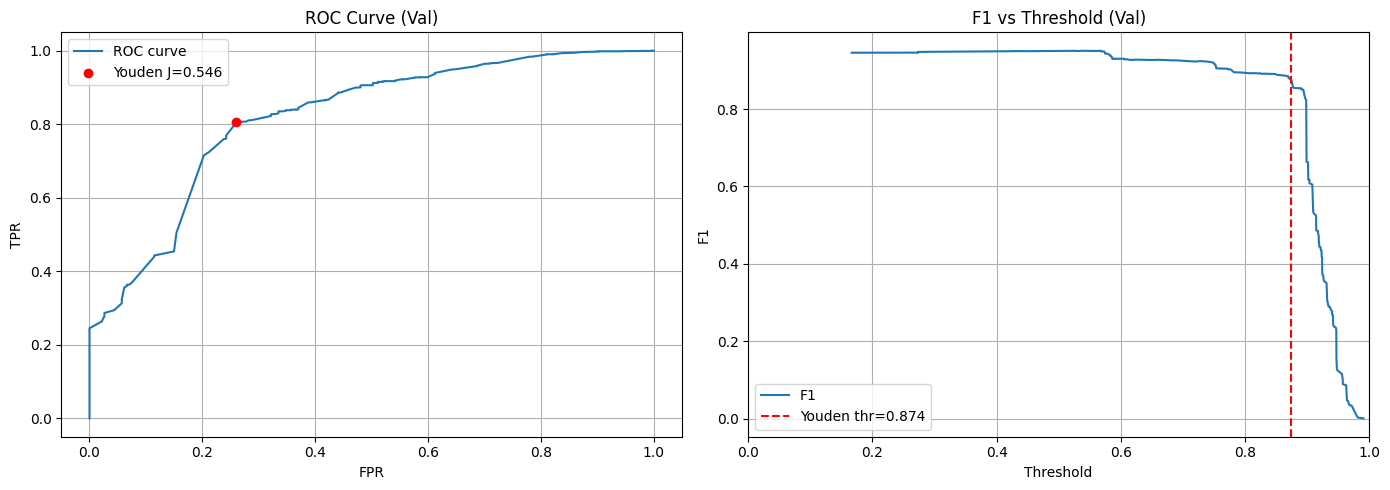

Threshold Youden: 0.8741   J=0.5463


In [54]:
# Youden's J threshold on val set
fpr, tpr, thresholds = roc_curve(y_val, best_prob_val)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
threshold_youden = thresholds[best_idx]
youden_j = j_scores[best_idx]

# F1 curve for comparison
f1s = [f1_score(y_val, (best_prob_val >= t).astype(int)) for t in thresholds]
best_f1_idx = np.nanargmax(f1s)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(fpr, tpr, label="ROC curve")
ax[0].scatter(fpr[best_idx], tpr[best_idx], c="red", zorder=5, label=f"Youden J={youden_j:.3f}")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[0].set_title("ROC Curve (Val)"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(thresholds, f1s, label="F1"); ax[1].axvline(threshold_youden, color="r", linestyle="--", label=f"Youden thr={threshold_youden:.3f}")
ax[1].set_xlabel("Threshold"); ax[1].set_ylabel("F1"); ax[1].set_xlim(0, 1); ax[1].set_title("F1 vs Threshold (Val)"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

print(f"Threshold Youden: {threshold_youden:.4f}   J={youden_j:.4f}")

In [55]:
# ── Stage 1 Final Evaluation on TEST OOT ──
pred_test = (best_prob_test >= threshold_youden).astype(int)

roc_test_final = roc_auc_score(y_test, best_prob_test)
pr_test_final  = average_precision_score(y_test, best_prob_test)
f1_test_final  = f1_score(y_test, pred_test)
brier_test_final = brier_score_loss(y_test, best_prob_test)

print("=" * 50)
print("STAGE 1 — Test OOT Evaluation")
print("=" * 50)
print(f"ROC-AUC : {roc_test_final:.4f}")
print(f"PR-AUC  : {pr_test_final:.4f}")
print(f"F1 (thr={threshold_youden:.3f}) : {f1_test_final:.4f}")
print(f"Brier   : {brier_test_final:.4f}")
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, pred_test))

STAGE 1 — Test OOT Evaluation
ROC-AUC : 0.5970
PR-AUC  : 0.9100
F1 (thr=0.874) : 0.9297
Brier   : 0.1050

Confusion matrix:
[[  25  537]
 [  76 4056]]


## Stage 2 — Regression: log_price_gns

### Strategy

Six models are trained on the regression subset (lots with recorded price) and compared on validation RMSE:

1. **Ridge Regression** — calibrated baseline (σ² estimated from out-of-sample residuals)
2. **Random Forest Regressor** — 25 Optuna trials, 4-fold temporal CV on RMSE
3. **XGBoost Regressor** — 50 Optuna trials, hist tree method, early stopping + MedianPruner
4. **LightGBM Regressor** — 50 Optuna trials, RMSE eval metric, early stopping + MedianPruner
5. **CatBoost Regressor** — 30 Optuna trials, temporal 80/20 eval for early stopping + MedianPruner
6. **Stacking Regressor** — Ridge meta-learner over the top 4 tree-model predictions on validation set

### Important Notes

- Stage 2 is evaluated **only on sold lots** (`sold_to_third_party == True`) in the test set
- σ² (residual variance) is estimated from out-of-sample validation predictions — never from training data
- Nominal price is computed as `exp(log_pred + σ² / 2)` (log-normal bias correction)

In [56]:
XR_train = reg_train[features_reg]
XR_val   = reg_val[features_reg]
XR_test  = reg_test[features_reg]
yR_train = reg_train['log_price_gns']
yR_val   = reg_val['log_price_gns']
yR_test  = reg_test['log_price_gns']

# Actual test prices — defined here so all regression cells can reference it
price_test_nominal = np.exp(yR_test)

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
with mlflow.start_run(run_name="baseline_ridge_regression"):
    alpha = 1.0
    ridge = Ridge(alpha=alpha, random_state=RANDOM_SEED)
    ridge.fit(XR_train, yR_train)

    pred_val_r = ridge.predict(XR_val)
    rmse_val   = np.sqrt(np.mean((yR_val - pred_val_r)**2))
    r2_val     = ridge.score(XR_val, yR_val)
    # sigma² from val residuals (out-of-sample) — avoids in-sample underestimation
    sigma2_ridge = np.var(yR_val - pred_val_r)

    mlflow.log_params({"alpha": alpha, "model": "Ridge"})
    mlflow.log_metrics({"val_rmse_log": rmse_val, "val_r2": r2_val})
    mlflow.sklearn.log_model(ridge, "model")

    print(f"Ridge | Val  RMSE={rmse_val:.4f}  R²={r2_val:.4f}  sigma²={sigma2_ridge:.4f}")

2026/05/11 18:11:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:11:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 18:11:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Ridge | Val  RMSE=1.3026  R²=0.0356  sigma²=1.3854


In [57]:
def objective_rf_reg(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 600)
    max_depth = trial.suggest_int("max_depth", 4, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5])

    rf = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth if max_depth < 20 else None,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        max_features=max_features, random_state=RANDOM_SEED, n_jobs=-1,
    )
    tscv = TimeSeriesSplit(n_splits=4)
    scores = -cross_val_score(rf, XR_train, yR_train, cv=tscv,
                               scoring="neg_root_mean_squared_error", n_jobs=1)
    return scores.mean()

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
_exp_id_reg = mlflow.get_experiment_by_name(MLFLOW_EXP_REG).experiment_id
mlf_cb_reg = MLflowCallback(
    metric_name="val_rmse_log",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_reg}
)

with mlflow.start_run(run_name="random_forest_reg_optuna"):
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective_rf_reg, n_trials=25, callbacks=[mlf_cb_reg])

    bp = study.best_params
    mlflow.log_params({"model": "RandomForestRegressor", **bp})

    rf_best_r = RandomForestRegressor(
        n_estimators=bp["n_estimators"], max_depth=bp["max_depth"] if bp["max_depth"] < 20 else None,
        min_samples_split=bp["min_samples_split"], min_samples_leaf=bp["min_samples_leaf"],
        max_features=bp["max_features"], random_state=RANDOM_SEED, n_jobs=-1
    )
    rf_best_r.fit(XR_train, yR_train)

    pred_val_rf_r = rf_best_r.predict(XR_val)
    rmse_val_rf   = np.sqrt(np.mean((yR_val - pred_val_rf_r)**2))
    r2_val_rf     = rf_best_r.score(XR_val, yR_val)
    sigma2_rf     = np.var(yR_val - pred_val_rf_r)

    mlflow.log_metrics({"val_rmse_log": rmse_val_rf, "val_r2": r2_val_rf})
    mlflow.sklearn.log_model(rf_best_r, "model")

    print(f"RF-Reg | Val  RMSE={rmse_val_rf:.4f}  R²={r2_val_rf:.4f}")

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_42780/4263580122.py:21: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlf_cb_reg = MLflowCallback(
2026/05/11 18:11:52 INFO mlflow.tracking.fluent: Experiment with name 'no-name-22dc4b94-0305-49f5-8705-5d99da6bd33d' does not exist. Creating a new experiment.
2026/05/11 18:12:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:12:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 18:13:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`

RF-Reg | Val  RMSE=1.1580  R²=0.2378


In [58]:
# ── XGBoost (Stage 2) — CPU multi-thread, hist tree method, early stopping ──
_split_idx_reg = int(len(XR_train) * 0.8)
_yr_reg = reg_train['sale_year']
assert _yr_reg.iloc[:_split_idx_reg].max() <= _yr_reg.iloc[_split_idx_reg:].min(), \
    "XGBoost reg split violates temporal order"

XR_tr, XR_ev = XR_train.iloc[:_split_idx_reg], XR_train.iloc[_split_idx_reg:]
yR_tr, yR_ev = yR_train.iloc[:_split_idx_reg], yR_train.iloc[_split_idx_reg:]

def objective_xgb_reg(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    pruning_cb = optuna.integration.XGBoostPruningCallback(trial, "validation_0-rmse")
    model = xgb.XGBRegressor(
        **params,
        tree_method="hist", device="cpu", n_jobs=-1,
        objective="reg:squarederror", eval_metric="rmse",
        random_state=RANDOM_SEED, early_stopping_rounds=30, verbosity=0,
        callbacks=[pruning_cb],
    )
    model.fit(XR_tr, yR_tr, eval_set=[(XR_ev, yR_ev)], verbose=False)
    pred = model.predict(XR_ev)
    return float(np.sqrt(np.mean((yR_ev - pred) ** 2)))

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
_exp_id_reg = mlflow.get_experiment_by_name(MLFLOW_EXP_REG).experiment_id
mlf_cb_xgbreg = MLflowCallback(
    metric_name="val_rmse_log",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_reg}
)

with mlflow.start_run(run_name="xgboost_reg_optuna"):
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_xgb_reg, n_trials=50, callbacks=[mlf_cb_xgbreg])

    bp = study.best_params
    mlflow.log_params({"model": "XGBoostRegressor", **bp})

    xgb_best_r = xgb.XGBRegressor(
        **bp,
        tree_method="hist", device="cpu", n_jobs=-1,
        objective="reg:squarederror",
        random_state=RANDOM_SEED, verbosity=0,
    )
    xgb_best_r.fit(XR_train, yR_train, verbose=False)

    pred_val_xgb_r = xgb_best_r.predict(XR_val)
    rmse_val_xgbr  = float(np.sqrt(np.mean((yR_val - pred_val_xgb_r) ** 2)))
    r2_val_xgbr    = xgb_best_r.score(XR_val, yR_val)
    sigma2_xgbr    = float(np.var(yR_val - pred_val_xgb_r))

    mlflow.log_metrics({"val_rmse_log": rmse_val_xgbr, "val_r2": r2_val_xgbr})
    mlflow.xgboost.log_model(xgb_best_r, "model")

    print(f"XGB-Reg | Val  RMSE={rmse_val_xgbr:.4f}  R²={r2_val_xgbr:.4f}")

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_42780/3628527263.py:34: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlf_cb_xgbreg = MLflowCallback(
2026/05/11 18:13:01 INFO mlflow.tracking.fluent: Experiment with name 'no-name-12d403c0-0910-4e6e-b862-d0dff7d5946a' does not exist. Creating a new experiment.
2026/05/11 18:13:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:13:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGB-Reg | Val  RMSE=1.1592  R²=0.2362


In [59]:
# ── LightGBM (Stage 2) — CPU multi-thread, RMSE eval ──
def objective_lgbm_reg(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }
    pruning_cb = optuna.integration.LightGBMPruningCallback(trial, "rmse")
    model = lgb.LGBMRegressor(
        **params,
        objective="regression", metric="rmse",
        random_state=RANDOM_SEED, n_jobs=-1, subsample_freq=1, verbose=-1,
    )
    model.fit(
        XR_tr, yR_tr,
        eval_set=[(XR_ev, yR_ev)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(30, verbose=False), pruning_cb],
    )
    pred = model.predict(XR_ev)
    return float(np.sqrt(np.mean((yR_ev - pred) ** 2)))

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
_exp_id_reg = mlflow.get_experiment_by_name(MLFLOW_EXP_REG).experiment_id
mlf_cb_lgbmreg = MLflowCallback(
    metric_name="val_rmse_log",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_reg}
)

with mlflow.start_run(run_name="lightgbm_reg_optuna"):
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_lgbm_reg, n_trials=50, callbacks=[mlf_cb_lgbmreg])

    bp = study.best_params
    mlflow.log_params({"model": "LightGBMRegressor", **bp})

    lgbm_best_r = lgb.LGBMRegressor(
        **bp,
        objective="regression",
        random_state=RANDOM_SEED, n_jobs=-1, subsample_freq=1, verbose=-1,
    )
    lgbm_best_r.fit(XR_train, yR_train)

    pred_val_lgbm_r = lgbm_best_r.predict(XR_val)
    rmse_val_lgbmr  = float(np.sqrt(np.mean((yR_val - pred_val_lgbm_r) ** 2)))
    r2_val_lgbmr    = lgbm_best_r.score(XR_val, yR_val)
    sigma2_lgbmr    = float(np.var(yR_val - pred_val_lgbm_r))

    mlflow.log_metrics({"val_rmse_log": rmse_val_lgbmr, "val_r2": r2_val_lgbmr})
    mlflow.lightgbm.log_model(lgbm_best_r, "model")

    print(f"LGBM-Reg | Val  RMSE={rmse_val_lgbmr:.4f}  R²={r2_val_lgbmr:.4f}")

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_42780/283783463.py:30: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlf_cb_lgbmreg = MLflowCallback(
2026/05/11 18:13:21 INFO mlflow.tracking.fluent: Experiment with name 'no-name-395fd969-526b-43c0-bffa-c52e6644c871' does not exist. Creating a new experiment.
2026/05/11 18:14:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:14:22 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 18:14:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` wil

LGBM-Reg | Val  RMSE=1.1591  R²=0.2363


In [60]:
def objective_cb_reg(trial):
    iterations = trial.suggest_int("iterations", 200, 1000)
    lr = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    depth = trial.suggest_int("depth", 4, 10)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1, 10, log=True)

    split_idx = int(len(XR_train) * 0.8)

    train_years_reg = reg_train['sale_year']
    first_half_max = train_years_reg.iloc[:split_idx].max()
    second_half_min = train_years_reg.iloc[split_idx:].min()
    assert first_half_max <= second_half_min, (
        f"CatBoost reg split violates temporal order: "
        f"first 80% max year={first_half_max}, last 20% min year={second_half_min}"
    )

    cb = CatBoostRegressor(
        iterations=iterations, learning_rate=lr, depth=depth, l2_leaf_reg=l2_leaf_reg,
        loss_function="RMSE", random_seed=RANDOM_SEED, verbose=False,
        thread_count=-1, early_stopping_rounds=50,
    )
    cb.fit(XR_train.iloc[:split_idx], yR_train.iloc[:split_idx],
           eval_set=(XR_train.iloc[split_idx:], yR_train.iloc[split_idx:]), use_best_model=True)
    return cb.best_score_['validation']['RMSE']

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
_exp_id_reg = mlflow.get_experiment_by_name(MLFLOW_EXP_REG).experiment_id
mlf_cb_reg2 = MLflowCallback(
    metric_name="val_rmse_log",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_reg}
)

with mlflow.start_run(run_name="catboost_reg_optuna"):
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_cb_reg, n_trials=30, callbacks=[mlf_cb_reg2])

    bp = study.best_params
    mlflow.log_params({"model": "CatBoostRegressor", **bp})

    cb_best_r = CatBoostRegressor(
        iterations=bp["iterations"], learning_rate=bp["learning_rate"],
        depth=bp["depth"], l2_leaf_reg=bp["l2_leaf_reg"],
        loss_function="RMSE", random_seed=RANDOM_SEED, verbose=False,
        thread_count=-1, early_stopping_rounds=50,
    )
    cb_best_r.fit(XR_train, yR_train, verbose=False)

    pred_val_cb_r = cb_best_r.predict(XR_val)
    rmse_val_cb   = np.sqrt(np.mean((yR_val - pred_val_cb_r)**2))
    r2_val_cb     = cb_best_r.score(XR_val, yR_val)
    sigma2_cb     = np.var(yR_val - pred_val_cb_r)

    mlflow.log_metrics({"val_rmse_log": rmse_val_cb, "val_r2": r2_val_cb})
    mlflow.catboost.log_model(cb_best_r, "model")

    print(f"CB-Reg | Val  RMSE={rmse_val_cb:.4f}  R²={r2_val_cb:.4f}")

/var/folders/4v/x8v2stmx1s1bm_jyf9xtxv_r0000gn/T/ipykernel_42780/922110940.py:29: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlf_cb_reg2 = MLflowCallback(
2026/05/11 18:14:25 INFO mlflow.tracking.fluent: Experiment with name 'no-name-e4768733-bb04-4540-b800-7c01ef90e2c0' does not exist. Creating a new experiment.
2026/05/11 18:14:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:14:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


CB-Reg | Val  RMSE=1.1879  R²=0.1979


In [61]:
# ── Stage 2 Stacking — val-based, Ridge meta-learner ──
pred_test_rf_r   = rf_best_r.predict(XR_test)
pred_test_xgb_r  = xgb_best_r.predict(XR_test)
pred_test_lgbm_r = lgbm_best_r.predict(XR_test)
pred_test_cb_r   = cb_best_r.predict(XR_test)

Z_val_reg  = np.column_stack([pred_val_rf_r,  pred_val_xgb_r,  pred_val_lgbm_r,  pred_val_cb_r])
Z_test_reg = np.column_stack([pred_test_rf_r, pred_test_xgb_r, pred_test_lgbm_r, pred_test_cb_r])

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
with mlflow.start_run(run_name="stacking_regressor"):
    meta_reg = Ridge(alpha=1.0, random_state=RANDOM_SEED)
    meta_reg.fit(Z_val_reg, yR_val)

    pred_val_stk_r  = meta_reg.predict(Z_val_reg)
    pred_test_stk_r = meta_reg.predict(Z_test_reg)

    rmse_val_stkr = float(np.sqrt(np.mean((yR_val - pred_val_stk_r) ** 2)))
    r2_val_stkr   = meta_reg.score(Z_val_reg, yR_val)
    sigma2_stkr   = float(np.var(yR_val - pred_val_stk_r))

    weights_r = dict(zip(["rf", "xgb", "lgbm", "cb"], meta_reg.coef_.round(4)))
    mlflow.log_params({"model": "StackingRegressor", "meta": "Ridge", **{f"w_{k}": v for k, v in weights_r.items()}})
    mlflow.log_metrics({"val_rmse_log": rmse_val_stkr, "val_r2": r2_val_stkr})
    mlflow.sklearn.log_model(meta_reg, "model")

    print(f"Stacking-Reg | Val  RMSE={rmse_val_stkr:.4f}  R²={r2_val_stkr:.4f}")
    print(f"Meta-learner weights: {weights_r}")

2026/05/11 18:14:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 18:14:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 18:14:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Stacking-Reg | Val  RMSE=1.1460  R²=0.2535
Meta-learner weights: {'rf': np.float64(0.1572), 'xgb': np.float64(0.5452), 'lgbm': np.float64(0.5222), 'cb': np.float64(-0.2521)}


In [62]:
# Stage 2 comparison — val metrics across all 6 models (Ridge, RF, XGB, LGBM, CB, Stacking)
# IMPORTANT: filter out nested Optuna trial runs — keep only the 6 top-level.
TOP_REG_RUNS = {
    "baseline_ridge_regression",
    "random_forest_reg_optuna",
    "xgboost_reg_optuna",
    "lightgbm_reg_optuna",
    "catboost_reg_optuna",
    "stacking_regressor",
}

client = MlflowClient()
exp2 = client.get_experiment_by_name(MLFLOW_EXP_REG)
all_runs2 = client.search_runs(exp2.experiment_id)
runs2 = [r for r in all_runs2 if r.info.run_name in TOP_REG_RUNS]

data2 = []
for r in runs2:
    p = r.data.params
    m = r.data.metrics
    data2.append({
        "run": r.info.run_name,
        "model": p.get("model", "?"),
        "val_rmse_log": round(m.get("val_rmse_log", 0), 4),
        "val_r2": round(m.get("val_r2", 0), 4),
    })

display(pd.DataFrame(data2).sort_values("val_rmse_log", ascending=True))

# ── Winner selection: in-memory RMSE (independent of MLflow query state) ──
def _rmse(y_true, y_pred): return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))
_rmse_in_memory = {
    "baseline_ridge_regression": _rmse(yR_val, ridge.predict(XR_val)),
    "random_forest_reg_optuna":  _rmse(yR_val, rf_best_r.predict(XR_val)),
    "xgboost_reg_optuna":        _rmse(yR_val, xgb_best_r.predict(XR_val)),
    "lightgbm_reg_optuna":       _rmse(yR_val, lgbm_best_r.predict(XR_val)),
    "catboost_reg_optuna":       _rmse(yR_val, cb_best_r.predict(XR_val)),
    "stacking_regressor":        _rmse(yR_val, pred_val_stk_r),
}
best_reg_run_name = min(_rmse_in_memory, key=_rmse_in_memory.get)
print(f"\nStage 2 winner: {best_reg_run_name}  (val_rmse_log={_rmse_in_memory[best_reg_run_name]:.4f})")
# Look up MLflow run for run_id export and tagging
best_reg_run = next((r for r in runs2 if r.info.run_name == best_reg_run_name), None)
if best_reg_run:
    client.set_tag(best_reg_run.info.run_id, "is_best", "True")
    client.set_tag(best_reg_run.info.run_id, "selection_reason", "lowest_val_rmse_log_among_6_models")

# Map winning run name to artifact + sigma² for downstream cell
from src.model_wrappers import StackingRegressorWrapper

stacking_reg_wrapper = StackingRegressorWrapper(
    base_models={"rf": rf_best_r, "xgb": xgb_best_r, "lgbm": lgbm_best_r, "cb": cb_best_r},
    meta=meta_reg,
    base_keys=["rf", "xgb", "lgbm", "cb"],
)

reg_candidates = {
    "baseline_ridge_regression": (ridge,                sigma2_ridge),
    "random_forest_reg_optuna":  (rf_best_r,            sigma2_rf),
    "xgboost_reg_optuna":        (xgb_best_r,           sigma2_xgbr),
    "lightgbm_reg_optuna":       (lgbm_best_r,          sigma2_lgbmr),
    "catboost_reg_optuna":       (cb_best_r,            sigma2_cb),
    "stacking_regressor":        (stacking_reg_wrapper, sigma2_stkr),
}
reg_best_model, sigma2_reg = reg_candidates[best_reg_run_name]
print(f"Selected artifact: {type(reg_best_model).__name__}  |  sigma²={sigma2_reg:.4f}")

,run,model,val_rmse_log,val_r2
38,stacking_regressor,StackingRegressor,1.1451,0.2548
36,stacking_regressor,StackingRegressor,1.1451,0.2548
30,stacking_regressor,StackingRegressor,1.1451,0.2548
24,stacking_regressor,StackingRegressor,1.1451,0.2548
18,stacking_regressor,StackingRegressor,1.1451,0.2548
12,stacking_regressor,StackingRegressor,1.1451,0.2548
0,stacking_regressor,StackingRegressor,1.1460,0.2535
6,stacking_regressor,StackingRegressor,1.1460,0.2535
22,random_forest_reg_optuna,RandomForestRegressor,1.1572,0.2388
34,random_forest_reg_optuna,RandomForestRegressor,1.1572,0.2388



Stage 2 winner: stacking_regressor  (val_rmse_log=1.1460)
Selected artifact: StackingRegressorWrapper  |  sigma²=1.3134


In [63]:
# ── Stage 2 Final Evaluation on TEST OOT — sold_to_third_party only ──
# regression_ready includes vendor buybacks (price recorded but not a third-party sale).
# sold_to_third_party lives in classification_ready; merge it in via sale_year+day+lot.
_keys = ['lot_uid'] if 'lot_uid' in reg_test.columns and 'lot_uid' in clf_test.columns else ['sale_name', 'sale_year', 'day', 'lot']
_sold_info = clf_test[_keys + ['sold_to_third_party']].copy()
_aug = reg_test[_keys].merge(_sold_info, on=_keys, how='left')
sold_mask = _aug['sold_to_third_party'].fillna(False).to_numpy().astype(bool)

XR_test_sold = XR_test[sold_mask]
yR_test_sold = yR_test[sold_mask]
print(f"reg_test rows: {len(reg_test)} | sold-to-third-party: {sold_mask.sum()} | vendor buyback filtered: {(~sold_mask).sum()}")

# reg_best_model and sigma2_reg were set in the previous winner-selection cell
print(f"Stage 2 winner artifact: {type(reg_best_model).__name__}  |  sigma²={sigma2_reg:.4f}")

reg_best_pred    = reg_best_model.predict(XR_test_sold)
price_test_sold  = np.exp(yR_test_sold)
price_pred_final = np.exp(reg_best_pred + sigma2_reg / 2)

rmse_final  = np.sqrt(np.mean((yR_test_sold - reg_best_pred)**2))
r2_final    = 1 - np.sum((yR_test_sold - reg_best_pred)**2) / np.sum((yR_test_sold - yR_test_sold.mean())**2)
mape_final  = np.mean(np.abs(price_test_sold - price_pred_final) / price_test_sold) * 100
mdape_final = np.median(np.abs(price_test_sold - price_pred_final) / price_test_sold) * 100

print("=" * 50)
print("STAGE 2 — Test OOT (SOLD TO THIRD PARTY ONLY)")
print("=" * 50)
print(f"RMSE (log) : {rmse_final:.4f}")
print(f"R²   (log) : {r2_final:.4f}")
print(f"MAPE       : {mape_final:.2f}%")
print(f"MdAPE      : {mdape_final:.2f}%")
print(f"N rows     : {sold_mask.sum()}")

reg_test rows: 4132 | sold-to-third-party: 4132 | vendor buyback filtered: 0
Stage 2 winner artifact: StackingRegressorWrapper  |  sigma²=1.3134
STAGE 2 — Test OOT (SOLD TO THIRD PARTY ONLY)
RMSE (log) : 1.1540
R²   (log) : 0.2473
MAPE       : 219.52%
MdAPE      : 68.61%
N rows     : 4132


## Qualitative Analysis — RNA / Buyback Horses

### What Are We Testing?

RNA ("Reserve Not Attained") lots have no observable transaction price — only a final bid below the reserve. This creates a **selection bias**: lots that fail to sell may systematically differ in quality from those that do.

### Approach

We apply the trained Stage 2 regressor to the full `inference_universe` (~18,989 lots, sold + RNA) and compare predicted latent-price distributions:

| Population | Observable Price? | What We Measure |
|---|---|---|
| **Sold** | Yes | Model prediction vs. ground truth (calibration check) |
| **RNA / Buyback** | No | Latent price predicted by the model |

### Key Questions

- Does the model assign systematically lower predicted prices to RNA horses?
- How do `P(sold)` and predicted price interact? (Hurdle diagnostic)
- Which RNA lots does the model flag as high-value despite not selling?

In [64]:
# Apply Stage 2 to the full inference universe (sold + RNA lots)
# Safety check: all reg features must exist in the inference universe
missing = [f for f in features_reg if f not in univ_df.columns]
assert len(missing) == 0, f"Missing features in inference_universe: {missing}"
# Also check for NaN values in feature columns
nan_counts = univ_df[features_reg].isna().sum()
if nan_counts.sum() > 0:
    cols_with_nan = nan_counts[nan_counts > 0]
    print(f"WARNING: {len(cols_with_nan)} features have NaN values in inference_universe:")
    for col, cnt in cols_with_nan.items():
        print(f"  {col}: {cnt} NaN(s)")
    print("Filling NaN with 0 — verify this is appropriate for each feature.")
X_univ = univ_df[features_reg].fillna(0)
log_price_all = reg_best_model.predict(X_univ)

univ_df['log_price_pred']     = log_price_all
univ_df['price_nominal_pred'] = np.exp(log_price_all + sigma2_reg / 2)

# Stage 1 probabilities — `clf_final` is the (possibly calibrated) classifier selected above
clf_best_proba_all = clf_final.predict_proba(univ_df[features_clf])[:, 1]
univ_df['prob_sold'] = clf_best_proba_all

print(univ_df[['sale_year', 'sold_to_third_party', 'prob_sold', 'price_nominal_pred']].head())

   sale_year  sold_to_third_party  prob_sold  price_nominal_pred
0       2009                 True   0.898810         3408.763498
1       2009                 True   0.898810        21462.944381
2       2009                 True   0.874734        14519.144746
3       2009                 True   0.870070        17176.999759
4       2009                 True   0.894146        18330.799467


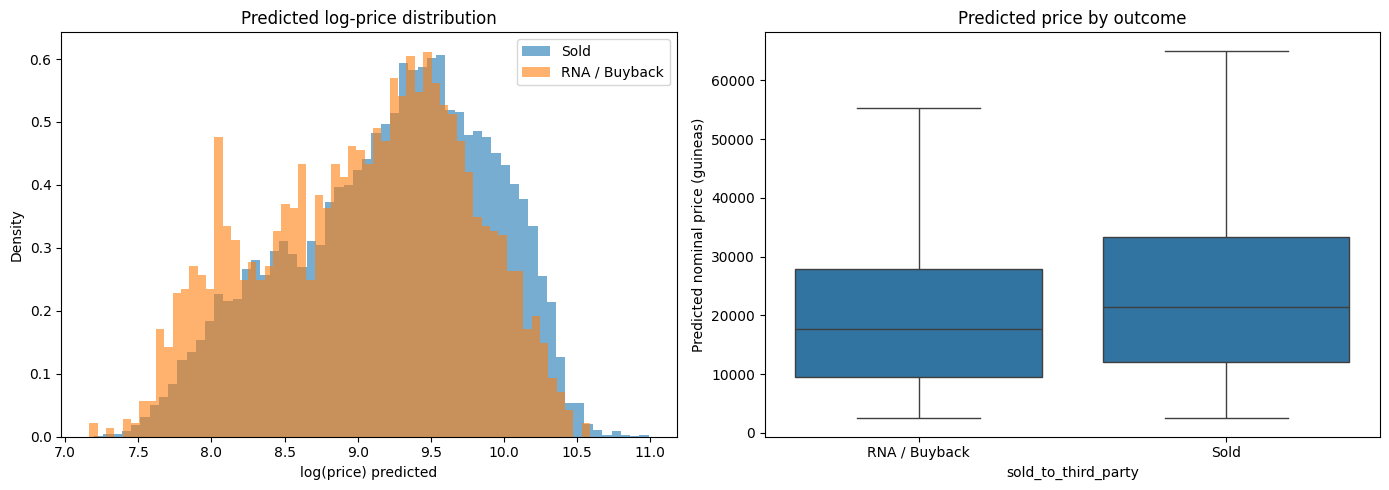

                           median          mean           std  count
sold_to_third_party                                                 
False                17751.206537  20372.205408  13340.440165   2462
True                 21402.639307  24215.599930  15022.277056  16527


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# log-price distributions
sold_mask_all = univ_df['sold_to_third_party'] == True
rna_mask_all  = sold_mask_all == False

axes[0].hist(univ_df.loc[sold_mask_all, 'log_price_pred'], bins=60, alpha=0.6, label='Sold', density=True)
axes[0].hist(univ_df.loc[rna_mask_all,  'log_price_pred'], bins=60, alpha=0.6, label='RNA / Buyback', density=True)
axes[0].set_xlabel("log(price) predicted"); axes[0].set_ylabel("Density"); axes[0].legend(); axes[0].set_title("Predicted log-price distribution")

# nominal price boxplot
sns.boxplot(data=univ_df, x='sold_to_third_party', y='price_nominal_pred', showfliers=False, ax=axes[1])
axes[1].set_xticklabels(["RNA / Buyback", "Sold"]); axes[1].set_ylabel("Predicted nominal price (guineas)"); axes[1].set_title("Predicted price by outcome")
plt.tight_layout(); plt.show()

# Summary stats
summary = univ_df.groupby('sold_to_third_party')['price_nominal_pred'].agg(['median','mean','std','count'])
print(summary)

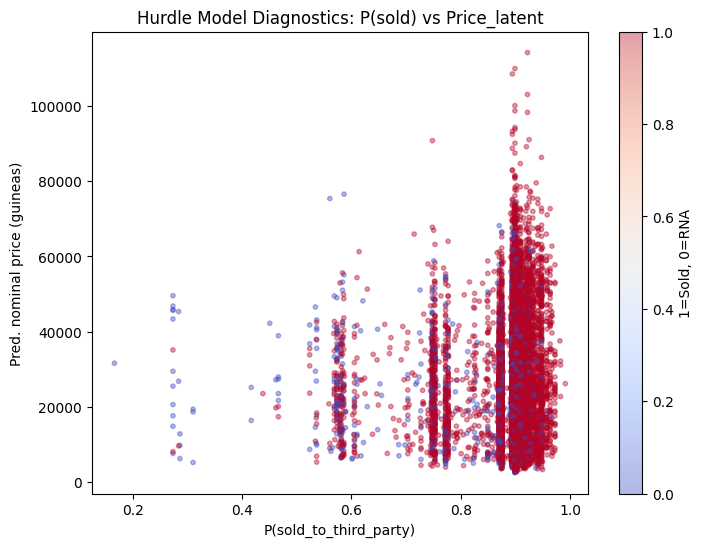

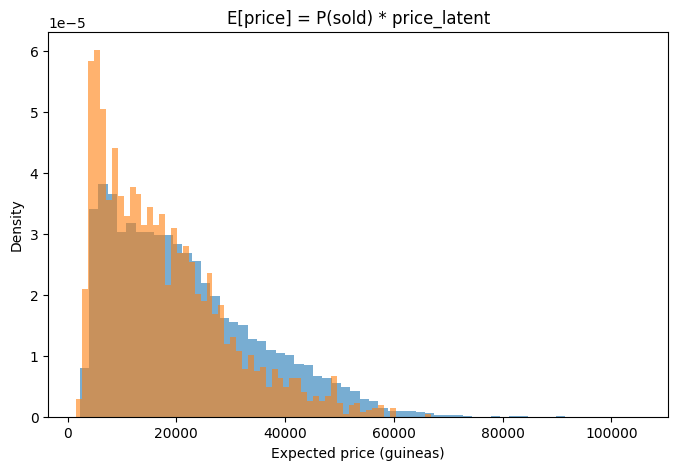

In [66]:
# Hurdle combined price expectation
univ_df['expected_price'] = univ_df['prob_sold'] * univ_df['price_nominal_pred']

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(univ_df['prob_sold'], univ_df['price_nominal_pred'],
                     c=univ_df['sold_to_third_party'], cmap='coolwarm', alpha=0.4, s=10)
ax.set_xlabel("P(sold_to_third_party)")
ax.set_ylabel("Pred. nominal price (guineas)")
ax.set_title("Hurdle Model Diagnostics: P(sold) vs Price_latent")
plt.colorbar(scatter, label="1=Sold, 0=RNA")
plt.show()

# E[price] distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(univ_df.loc[sold_mask_all, 'expected_price'], bins=60, alpha=0.6, label='Sold', density=True)
ax.hist(univ_df.loc[rna_mask_all,  'expected_price'], bins=60, alpha=0.6, label='RNA', density=True)
ax.set_xlabel("Expected price (guineas)"); ax.set_ylabel("Density"); ax.set_title("E[price] = P(sold) * price_latent")
plt.show()

In [67]:
top_rna = univ_df[~sold_mask_all].nlargest(10, 'price_nominal_pred')
print("Top 10 RNA lots by predicted latent price:")
print(top_rna[['price_nominal_pred', 'prob_sold', 'expected_price', 'sale_year']].head(10))

Top 10 RNA lots by predicted latent price:
       price_nominal_pred  prob_sold  expected_price  sale_year
12640        76565.136872   0.586415    44898.952031       2020
12169        75383.916287   0.560401    42245.245471       2020
14653        74437.142221   0.898810    66904.856965       2022
16741        68170.287870   0.870070    59312.903756       2024
5783         67349.315685   0.894146    60220.138131       2014
13012        66294.256280   0.874734    57989.813392       2020
15764        66229.472539   0.898810    59527.720367       2023
16057        66217.373899   0.897053    59400.508993       2023
17481        64866.922118   0.894146    58000.515229       2024
14859        64170.464405   0.901717    57863.605061       2022


In [68]:
# Export best run IDs for 05_Model_Audit.ipynb
BEST_CLF_RUN_ID = best_run.info.run_id
BEST_REG_RUN_ID = best_reg_run.info.run_id

print(f"BEST_CLF_RUN_ID = '{BEST_CLF_RUN_ID}'")
print(f"BEST_REG_RUN_ID = '{BEST_REG_RUN_ID}'")

# Save to JSON for easy loading
with open("best_run_ids.json", "w") as f:
    json.dump({
        "stage1_classification": BEST_CLF_RUN_ID,
        "stage2_regression": BEST_REG_RUN_ID,
        "threshold_youden": float(threshold_youden),
        "best_classifier_model": best_run.info.run_name,
        "best_regressor_model": best_reg_run.info.run_name,
    }, f, indent=2)
print("Saved to best_run_ids.json")

# Persist the exact final composed models used for downstream audit/inference.
# This saves the selected wrapper object, not a re-trained approximation.
from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(clf_final, models_dir / "stage1_final_model.joblib")
joblib.dump(reg_best_model, models_dir / "stage2_final_model.joblib")
with open(models_dir / "final_model_metadata.json", "w") as f:
    json.dump({
        "stage1_model": best_run.info.run_name,
        "stage1_run_id": BEST_CLF_RUN_ID,
        "stage2_model": best_reg_run.info.run_name,
        "stage2_run_id": BEST_REG_RUN_ID,
        "threshold_youden": float(threshold_youden),
        "sigma2_reg": float(sigma2_reg),
        "features_clf": features_clf,
        "features_reg": features_reg,
    }, f, indent=2)
print("Saved exact final model artifacts to ../models/")

BEST_CLF_RUN_ID = '0cc91766982648789f2caf4ff68e0cfe'
BEST_REG_RUN_ID = '2337a07fb428454eb4649adf2e3665e3'
Saved to best_run_ids.json
Saved exact final model artifacts to ../models/


In [69]:
import os
os.makedirs("../outputs/analyses", exist_ok=True)

# Export Classification
# Z_test_clf has probas for rf, xgb, lgbm, cb
clf_export = clf_test[[c for c in ['lot_uid', 'sale_name', 'sale_year', 'day', 'lot', 'sold_to_third_party'] if c in clf_test.columns]].copy()

clf_export['prob_rf'] = prob_test_rf
clf_export['prob_xgb'] = prob_test_xgb
clf_export['prob_lgbm'] = prob_test_lgbm
clf_export['prob_cb'] = prob_test_cb
clf_export['prob_stacking'] = best_prob_test
clf_export.to_parquet("../outputs/analyses/audit_clf_predictions.parquet")

# Export Regression
# test sold rows
reg_export = reg_test.loc[sold_mask, [c for c in ['lot_uid', 'sale_name', 'sale_year', 'day', 'lot'] if c in reg_test.columns]].copy()
reg_export['sold_to_third_party'] = True
reg_export['log_price_true'] = yR_test_sold
reg_export['log_price_pred_rf'] = pred_test_rf_r[sold_mask]
reg_export['log_price_pred_xgb'] = pred_test_xgb_r[sold_mask]
reg_export['log_price_pred_lgbm'] = pred_test_lgbm_r[sold_mask]
reg_export['log_price_pred_cb'] = pred_test_cb_r[sold_mask]
reg_export['log_price_pred_stacking'] = reg_best_pred
reg_export['sigma2'] = float(sigma2_reg)
reg_export.to_parquet("../outputs/analyses/audit_reg_predictions.parquet")

# Export Universe
univ_df.to_parquet("../outputs/analyses/audit_universe_predictions.parquet")
print("Exported audit data to outputs/analyses/")

Exported audit data to outputs/analyses/


## Modeling Conclusions & Future Directions

### 1. The Hurdle Model Architecture Validated
The two-stage approach successfully disentangles a horse's **intrinsic market value** (Stage 2) from its **market liquidity / sale risk** (Stage 1). A standard regression on all lots (e.g., filling RNA with zeros) would have destroyed the mathematical distribution, while entirely ignoring RNA lots would have yielded a model blind to market risk.

### 2. The RNA Paradox (Microeconomics of the Auction)
The model assigns **higher nominal predicted prices** (`price_nominal_pred`) to some RNA lots than to sold lots — horses with strong catalogue characteristics that did not find a buyer that day. However, when expected price is computed correctly as `expected_price = prob_sold × price_nominal_pred`, the result inverts: **sold lots have higher expected price than RNA lots**. This is the coherent finding: RNA lots have lower `prob_sold`, which discounts their nominal prediction enough to place their expected price below sold lots.

This is consistent with the hypothesis of **high reserve prices in premium segments** — not with market inefficiency. The model assigns a high nominal value to these horses and a low sale probability, precisely because elite-pedigree sellers set aggressive reserves that the room cannot always meet.

### 3. The Limits of Tabular Data (Stage 1 Stochasticity)
Stage 1 Classification yields a conservative ROC curve and PR-AUC. This is not a model failure, but a reflection of the domain: a sale's completion depends heavily on hidden variables—specifically, the **seller's secret reserve price** and the real-time emotional state of the auction room. Tabular data establishes a strong theoretical baseline, but the final hammer drop is highly stochastic.

### 4. Future Work: Multimodal Deep Learning
To capture the undocumented variables that dictate auction outcomes, future work should transition from purely tabular models to **Multimodal Deep Learning** using Tattersalls auction video and audio feeds:
* **Computer Vision (Conformation & Biomechanics):** Using Pose Estimation networks or Video Transformers (e.g., Video Swin) to analyze the horse's gait, physical symmetry, and temperament (e.g., nervousness) while walking the ring.
* **Audio Analysis (Auction Dynamics):** Processing the auctioneer's cadence and pitch, alongside audience noise levels, to detect real-time bidding wars and room expectation.

Integrating these multimodal embeddings with our current tabular features would bridge the gap between theoretical pedigree value and real-world auction liquidity.

In [70]:
!mlflow ui --port 5001



Backend store URI not provided. Using ./mlruns
Registry store URI not provided. Using backend store URI.
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/mlflow/server/handlers.py:377: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, artifact_uri)
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/mlflow/server/handlers.py:412: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store f

In [71]:
# Vendor buybacks tienen precio registrado pero sold_to_third_party == False
vb_mask = (univ_df['vendor_buyback'] == True)  # o como esté codificado

vb = univ_df[vb_mask].copy()
vb['model_above_buyback'] = vb['price_nominal_pred'] > vb['price_gns']

print(f"Vendor buybacks: {len(vb)}")
print(f"Modelo predice > precio buyback: {vb['model_above_buyback'].mean():.1%}")
print(f"Ratio mediano (pred/buyback): {(vb['price_nominal_pred'] / vb['price_gns']).median():.2f}")

Vendor buybacks: 1382
Modelo predice > precio buyback: 56.7%
Ratio mediano (pred/buyback): 1.17
